<a href="https://colab.research.google.com/github/salonigarje5/salonigarje5/blob/main/Placement_salary_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
data = pd.read_csv("Salary Data.csv")

print("First 5 rows:")
display(data.head())

print("\nDataset Info:")
data.info()

First 5 rows:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [7]:
print(data.columns)

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')


In [8]:
X = data[['Years of Experience']]
y = data['Salary']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
print(data.isnull().sum())

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [13]:
import numpy as np

# Replace hidden missing values
data.replace(['NA', 'null', ' '], np.nan, inplace=True)

# Drop missing rows
data = data.dropna()

# Reset index
data = data.reset_index(drop=True)

In [14]:
X = data[['Years of Experience']]
y = data['Salary']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 12094.170341194764
R2 Score: 0.8991338517367767


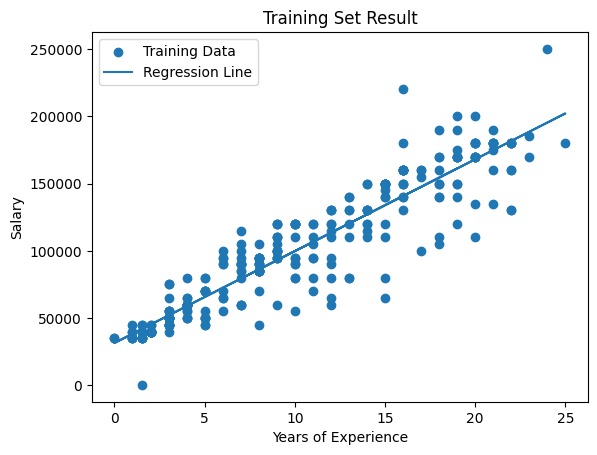

In [18]:
plt.scatter(X_train, y_train, label="Training Data")
plt.plot(X_train, model.predict(X_train), label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Training Set Result")
plt.legend()
plt.show()

In [23]:
exp = float(input("Enter Years of Experience: "))
predicted_salary = model.predict([[exp]])

print(f"Predicted Salary: ₹{predicted_salary[0]:.2f}")

Enter Years of Experience: 2
Predicted Salary: ₹45166.26


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
